# Introduction #
## PBA Week 3 ##
Mohammad Geresidi Rachmadi
5026221163 - Sistem Informasi

In [1]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn
!pip install nltk
!pip install Sastrawi
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.9 MB/s eta 0:00:00


## Data Collection ##

Initial Setup

In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
import nltk
from collections import Counter
from nltk.tokenize import word_tokenize
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import CountVectorizer

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

Get data from = "https://play.google.com/store/apps/details?id=com.seatech.bluebird&hl=en", Online Taxi Mobile Apps.

In [3]:
#https://play.google.com/store/apps/details?id=com.seatech.bluebird&hl=en


from google_play_scraper import app, Sort, reviews_all

mbb_reviews = reviews_all(
    'com.seatech.bluebird',
    sleep_milliseconds=0, # defaults to 0
    lang='en', # defaults to 'en'
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

Save data into DataFrame

In [4]:
df_mbbrev = pd.DataFrame(np.array(mbb_reviews),columns=['content'])
df_mbbrev = df_mbbrev.join(pd.DataFrame(df_mbbrev.pop('content').tolist()))

Mask Username

In [5]:
def mask_username(username):
    if pd.isna(username):
        return username
    username = str(username)
    if len(username) <= 4:
        return "*" * len(username)
    return username[:2] + "*" * (len(username)-4) + username[-2:]

df_mbbrev['userName'] = df_mbbrev['userName'].apply(mask_username)

Save raw data (with username masking) into .csv

In [6]:
df_mbbrev.to_csv("mybluebird_raw.csv", index=False)

In [7]:
df_mbbrev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c2c92730-0629-496a-86f7-52b2ebd72abf,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,Bikin aplikasi ga pakai UAT,1,0,None,2025-09-21 21:30:38,"Yth Bapak Tri Hartanto, mohon maaf atas ketida...",2025-09-21 21:45:11,None
1,702d58d1-030a-441b-b105-7eb005c17753,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,selalu gagal add payment method: credit card d...,4,0,6.19.0,2025-09-21 13:03:20,"Yth, Bapak/Ibu Haerun Nur​ , mohon maaf atas k...",2025-09-21 13:26:26,6.19.0
2,11cfd27e-fd4d-4ff1-8d38-271b2e1e1a9c,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,Perusahaan taksi andalan yang legendaris. Maju...,5,0,6.19.0,2025-09-16 08:01:56,"Dear Bapak/Ibu Harimurti Kridalaksana , terima...",2025-09-16 08:07:10,6.19.0
3,4fc0c4fe-bf6c-4ef6-979c-6102efc675cc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,getting better but can you please give the lic...,3,7,6.18.2,2025-09-15 10:20:12,"Good evening Bapa/Ibu J , Thank you for your r...",2025-09-15 10:55:29,6.18.2
4,0d1e4c23-7a76-4449-925f-2f069fdac414,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,"good app and service, but too many annoying ad...",4,0,6.18.2,2025-09-15 00:01:59,"Hi Mr Michael Vaughan , thank you for the rati...",2025-09-15 00:15:29,6.18.2
...,...,...,...,...,...,...,...,...,...,...,...
9665,2e7a5e6a-e376-47e4-b001-64fe97421afc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,Great app. Sangat membantu.,4,1,1.2.127,2011-12-07 23:57:37,None,NaT,1.2.127
9666,01814132-db78-47a4-914d-efd23e986e40,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,"Akhirnya setelah di blackberry, dibuat juga ap...",5,1,1.2.126,2011-12-07 02:58:14,None,NaT,1.2.126
9667,cdc031c1-088a-4619-928c-c7c1cd2d1e75,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,Pagi jam 4 saya pesan taksi berjalan dengan ba...,4,2,1.2.126,2011-12-02 22:11:34,None,NaT,1.2.126
9668,4d2cc639-e04a-40f5-86c8-d654a58f0886,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,Pertama kali make app ini gw seneng banget kar...,2,2,1.2.126,2011-11-30 02:24:32,None,NaT,1.2.126


In [8]:
df_mbbrev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9670 entries, 0 to 9669
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              9670 non-null   object        
 1   userName              9670 non-null   object        
 2   userImage             9670 non-null   object        
 3   content               9664 non-null   object        
 4   score                 9670 non-null   int64         
 5   thumbsUpCount         9670 non-null   int64         
 6   reviewCreatedVersion  8706 non-null   object        
 7   at                    9670 non-null   datetime64[ns]
 8   replyContent          8571 non-null   object        
 9   repliedAt             8571 non-null   datetime64[ns]
 10  appVersion            8706 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 831.1+ KB


## Data Preprocessing ##

Lowercasing

In [9]:
df_mbbrev['content'] = df_mbbrev['content'].astype(str)# Before lowercasing
# Before lowercasing
print ("Before lowercasing:")
print(df_mbbrev['content'][11])
print(df_mbbrev['content'][1])
print(df_mbbrev['content'][20])
print ("\nAfter lowercasing:")
df_mbbrev['content']= df_mbbrev['content'].apply(lambda x: x.lower())
print(df_mbbrev['content'][11])
print(df_mbbrev['content'][1])
print(df_mbbrev['content'][20])

Before lowercasing:
Annoying banget nggak bisa milih lokasi sesuai titik maps. Saya mau pilih lokasi di lobby G FKM UI tpi selalu mengarah ke RS UI karena data yang di apps adanya RS ui. Tolong dibuat agar titik penjemputan bisa dipilih sesuai titik yang sudah kita arahkan, jangan auto dipindahkan ke data area yang hanya dimiliki apps saja.
selalu gagal add payment method: credit card dengan error "one or more payload is invalid" (or something like that) padahal semua info benar.
I cancel the order. and still paying. 👎

After lowercasing:
annoying banget nggak bisa milih lokasi sesuai titik maps. saya mau pilih lokasi di lobby g fkm ui tpi selalu mengarah ke rs ui karena data yang di apps adanya rs ui. tolong dibuat agar titik penjemputan bisa dipilih sesuai titik yang sudah kita arahkan, jangan auto dipindahkan ke data area yang hanya dimiliki apps saja.
selalu gagal add payment method: credit card dengan error "one or more payload is invalid" (or something like that) padahal semua in

Tokenization

In [10]:
df_mbbrev['tokens'] = df_mbbrev['content'].str.lower().str.split()
all_tokens = [word for tokens in df_mbbrev['tokens'] for word in tokens]
counter = Counter(all_tokens)
top_50 = counter.most_common(50)
print(top_50)

[('the', 3162), ('to', 2447), ('and', 1678), ('tidak', 1672), ('i', 1623), ('di', 1553), ('dan', 1509), ('driver', 1475), ('bisa', 1425), ('saya', 1404), ('app', 1306), ('aplikasi', 1191), ('ada', 1043), ('taxi', 1035), ('is', 1006), ('yg', 964), ('ga', 902), ('it', 892), ('a', 874), ('order', 842), ('for', 832), ('my', 817), ('sudah', 798), ('yang', 760), ('in', 719), ('this', 704), ('good', 703), ('not', 695), ('untuk', 686), ('ke', 636), ('ini', 636), ('bluebird', 629), ('but', 583), ('blue', 575), ('apps', 573), ('sangat', 555), ('very', 554), ('gak', 521), ('nya', 511), ('you', 509), ('lebih', 506), ('tapi', 503), ('mau', 495), ('on', 487), ('of', 469), ('easy', 468), ('bird', 447), ('no', 447), ('use', 440), ('dari', 437)]


Stopword Removal

In [11]:
# Create stopword remover
factory = StopWordRemoverFactory()
id_stopwords = set(factory.get_stop_words())

# Apply stopword removal to the 'content' column
df_mbbrev['tokens_stopword_rm'] = df_mbbrev['tokens'].apply(lambda tokens: [w for w in tokens if w not in id_stopwords])

In [12]:
nltk.download('stopwords')

english_stopwords = set(stopwords.words('english'))

df_mbbrev['tokens_stopword_rm'] = df_mbbrev['tokens_stopword_rm'].apply(
    lambda tokens: [w for w in tokens if w not in english_stopwords]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
print("stopwords removed:")
print (id_stopwords)
print (english_stopwords)

stopwords removed:
{'setelah', 'lagi', 'oleh', 'tapi', 'bisa', 'terhadap', 'dsb', 'ok', 'itu', 'dst', 'sebetulnya', 'para', 'oh', 'selagi', 'apalagi', 'secara', 'tidak', 'kembali', 'jika', 'sampai', 'dia', 'amat', 'nanti', 'dalam', 'kemana', 'tolong', 'sementara', 'kecuali', 'telah', 'bagi', 'ketika', 'daripada', 'boleh', 'ya', 'untuk', 'juga', 'menurut', 'seolah', 'sudah', 'karena', 'lain', 'ingin', 'namun', 'guna', 'sebagai', 'pula', 'sesudah', 'kita', 'apakah', 'dari', 'saat', 'anda', 'sebab', 'harus', 'bagaimanapun', 'dll', 'agar', 'sehingga', 'pada', 'melainkan', 'kami', 'dengan', 'dan', 'sesuatu', 'nggak', 'pun', 'yang', 'ia', 'sedangkan', 'mengapa', 'dimana', 'mari', 'ke', 'dua', 'hal', 'pasti', 'tentang', 'kepada', 'seraya', 'maka', 'itulah', 'belum', 'dapat', 'saja', 'setidaknya', 'sekitar', 'seperti', 'adalah', 'yaitu', 'ada', 'selain', 'sebelum', 'begitu', 'ini', 'tanpa', 'mereka', 'seharusnya', 'di', 'hanya', 'dahulu', 'sambil', 'tetapi', 'supaya', 'serta', 'atau', 'kah', '

In [14]:
df_mbbrev['tokens_stopword_rm']

,tokens_stopword_rm
0,"[bikin, aplikasi, ga, pakai, uat]"
1,"[selalu, gagal, add, payment, method:, credit,..."
2,"[perusahaan, taksi, andalan, legendaris., maju..."
3,"[getting, better, please, give, licence, numbe..."
4,"[good, app, service,, many, annoying, adverts]"
...,...
9665,"[great, app., sangat, membantu.]"
9666,"[akhirnya, blackberry,, dibuat, aplikasi, buat..."
9667,"[pagi, jam, 4, pesan, taksi, berjalan, baik,, ..."
9668,"[pertama, kali, make, app, gw, seneng, banget,..."


Stemming

In [40]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk import pos_tag

# --- download resource nltk (sekali saja) ---
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# --- init tools ---
lemmatizer = WordNetLemmatizer()
factory = StemmerFactory()
indo_stemmer = factory.create_stemmer()

# slang mapping
slang_dict = {
    "ngga": "tidak",
    "ga": "tidak",
    "gk": "tidak",
    "nggak": "tidak",
    "yg": "yang",
    "tp": "tapi",
    "drivernya": "driver",
    "gpp" : "tidak apa-apa",
    "bgt" : "banget",
    "trs" : "terus",
    "td" : "tadi",
    "dmn" : "dimana",
    "kmn" : "kemana",
    "ap" : "apa",
    "jg" : "juga",
    "oke" : "baik",
    "bbrp" : "beberapa",
    "gw" : "saya",
    "sgt" : "sangat",
    "knp" : "kenapa",
    "skrg" : "sekarang",
    "cuma" : "hanya",
    "supir2" : "supir-supir",
    "udah" : "sudah",
    "milih" : "pilih",
    ":gabisa" : "tidak bisa"
}

# fungsi normalisasi 1 token
def normalize_word(w):
    w = w.lower()
    w = re.sub(r"[^\w]", "", w)  # buang tanda baca

    # slang replacement
    if w in slang_dict:
        return slang_dict[w]

    # buang sufiks umum Indo
    w = re.sub(r"(nya|lah|kah|pun|ku|mu)$", "", w)

    # buang prefix ter- (contoh: terkunci -> kunci)
    if w.startswith("ter") and len(w) > 4:
        w = w[3:]

    # English word
    if w.isascii() and w != "":
        pos = pos_tag([w])[0][1][0].upper()
        pos_map = {"J": "a", "N": "n", "V": "v", "R": "r"}
        return lemmatizer.lemmatize(w, pos_map.get(pos, "n"))

    # Indonesian word
    if w != "":
        return indo_stemmer.stem(w)

    return w

# --- apply ke seluruh dataframe ---
df_mbbrev["tokens_stemmed"] = df_mbbrev["tokens_stopword_rm"].apply(
    lambda tokens: [normalize_word(w) for w in tokens]
)

# cek hasil
print(df_mbbrev[["tokens_stopword_rm", "tokens_stemmed"]].head(15))


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


                                   tokens_stopword_rm  \
0                   [bikin, aplikasi, ga, pakai, uat]   
1   [selalu, gagal, add, payment, method:, credit,...   
2   [perusahaan, taksi, andalan, legendaris., maju...   
3   [getting, better, please, give, licence, numbe...   
4      [good, app, service,, many, annoying, adverts]   
5                          [nice, app,, thanks, 👍🏾👍🏾]   
6   [kualitas, telpon, sangat, buruk,, sulit, berk...   
7   [app, uses, algorithm, gojek, grab;, matching,...   
8                   [still, need, many, improvements]   
9   [udah, bagus,, cuma, kurang, pilihan, tadi, bl...   
10  [dear, bluebird,, knp, skrg, maps, nya, salah,...   
11  [annoying, banget, milih, lokasi, sesuai, titi...   
12  [aplikasi, sampah, gabisa, order, sama, sekali...   
13                  [fantastic, app, service, aaa+++]   
14  [aplikasi, bagus, banyak, supir2, baru, ga, ta...   

                                       tokens_stemmed  
0                [bikin, aplika

In [16]:
#Check number of reviews scores
df_mbbrev['score'].value_counts()

,count
score,
5,3911
1,3166
2,944
4,851
3,798


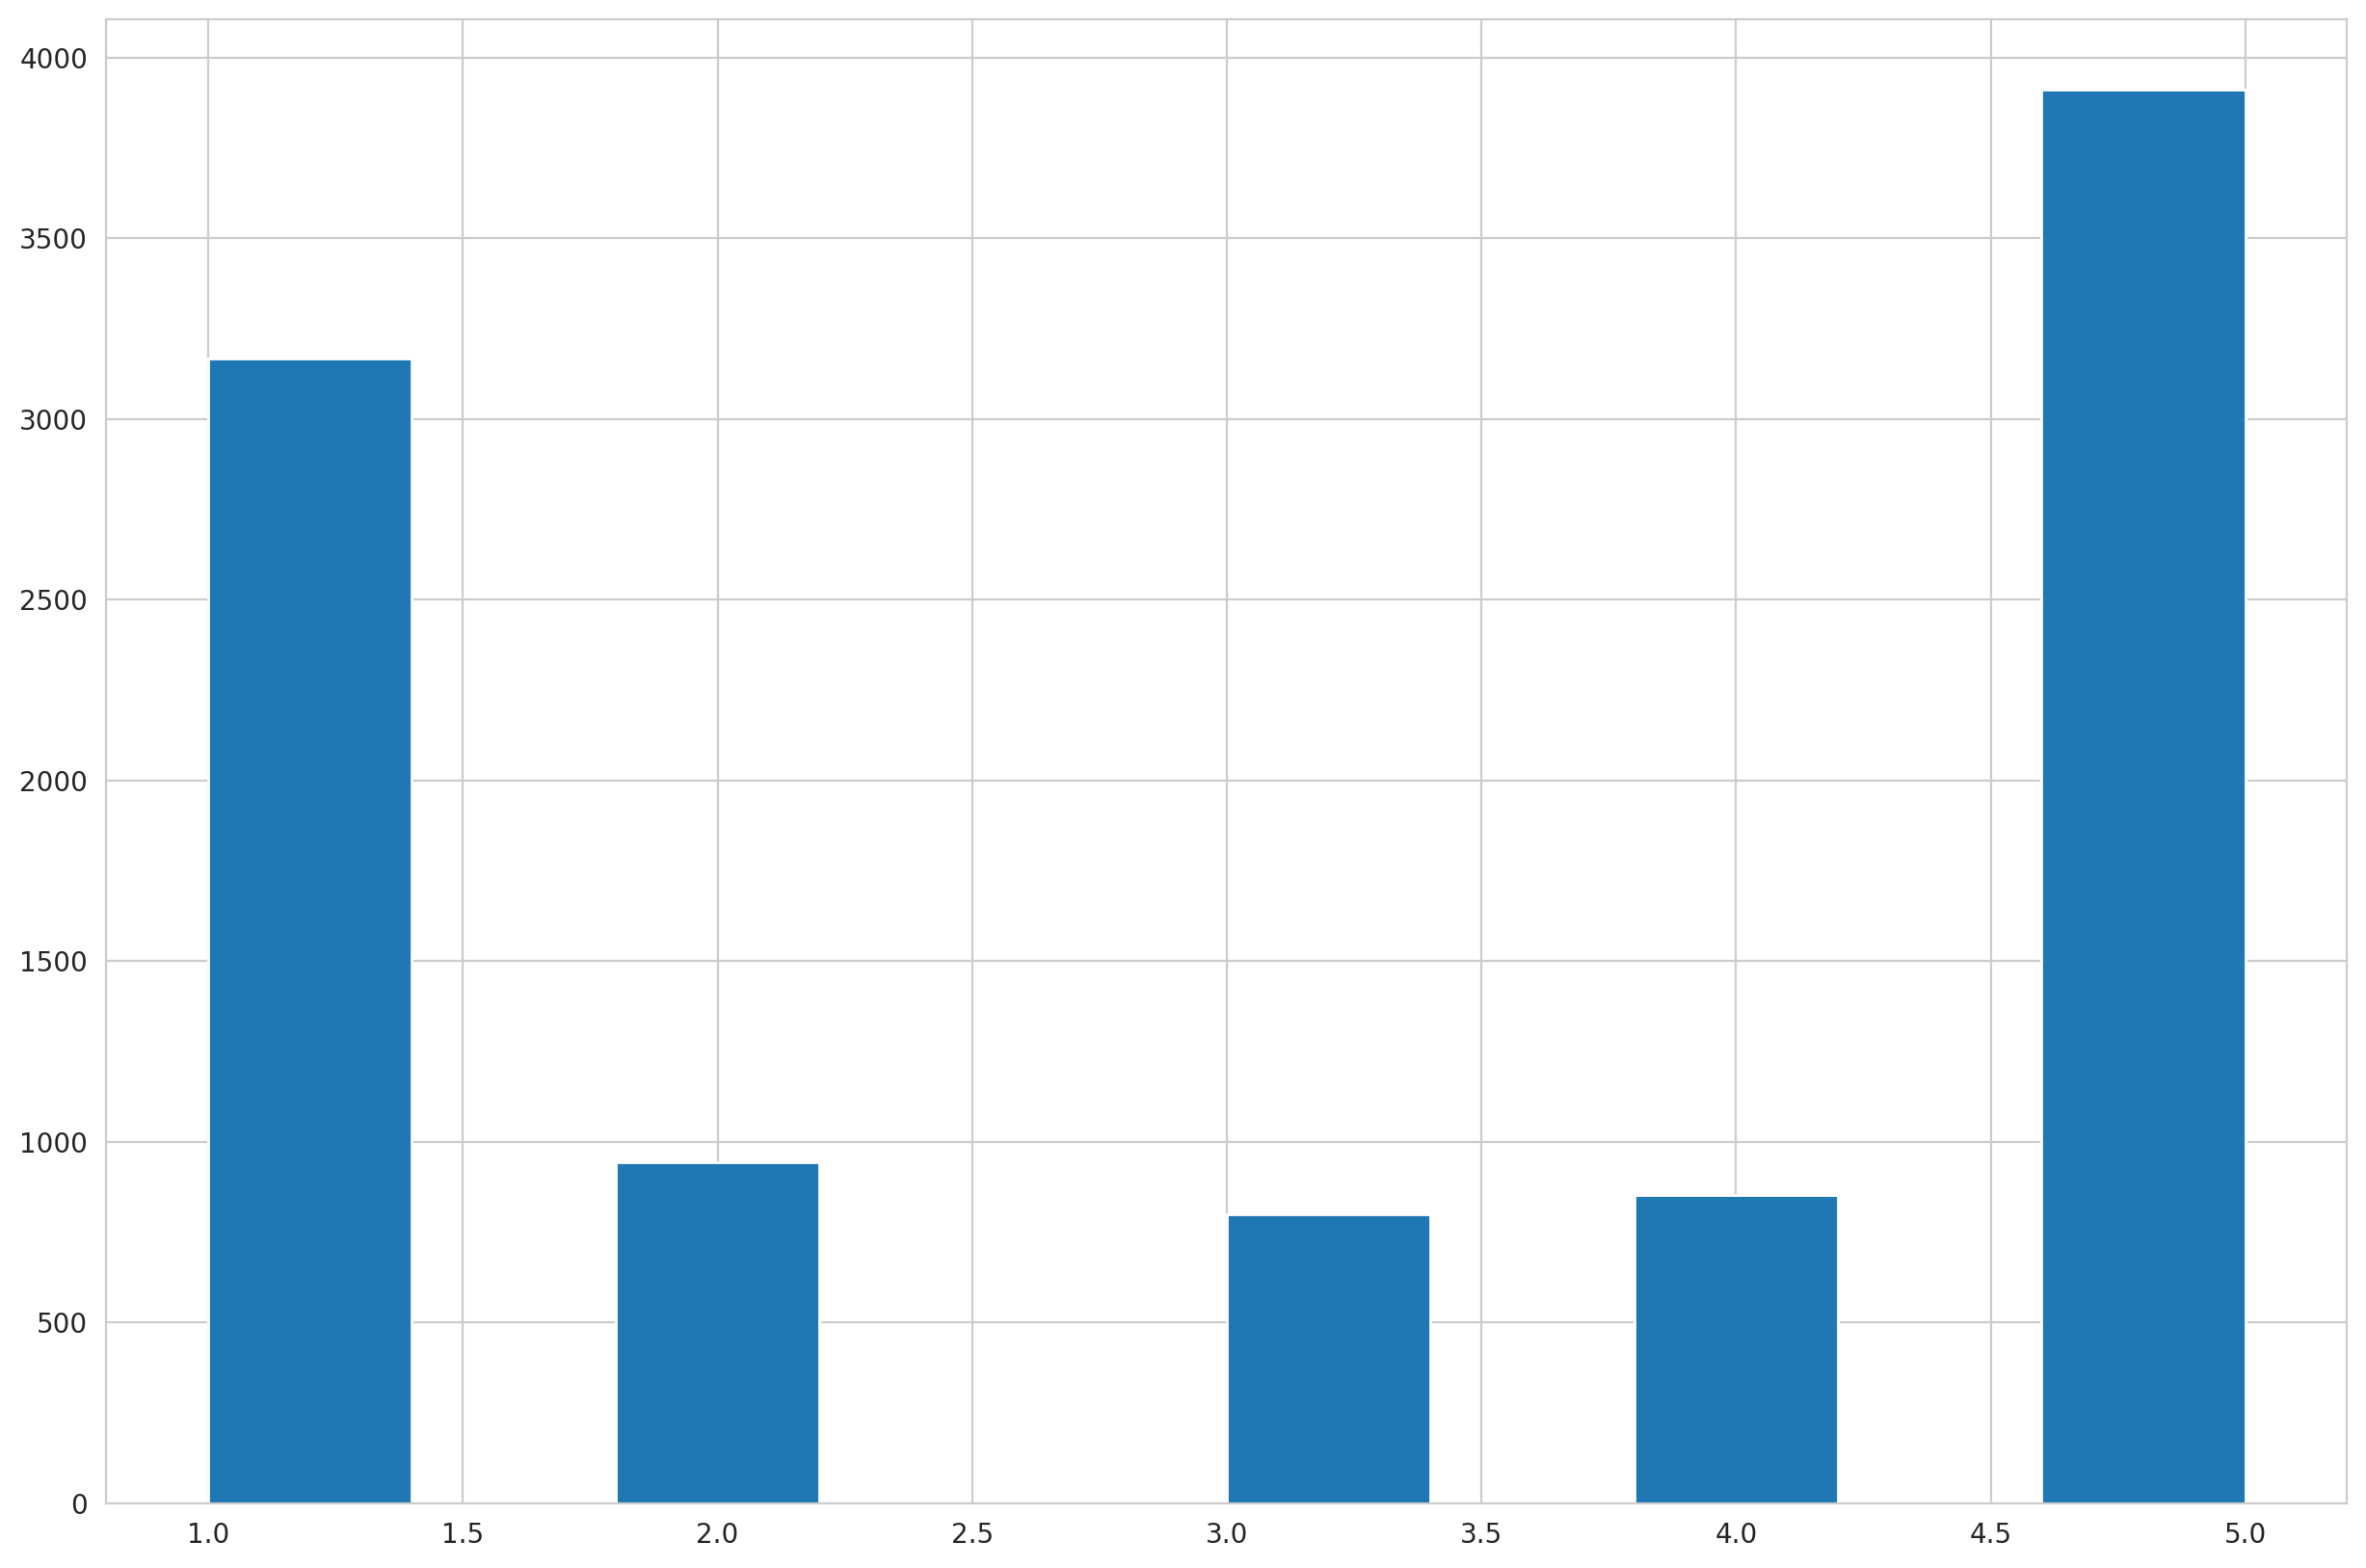

In [17]:
plt.hist(df_mbbrev['score'])
plt.show()

In [18]:
df_mbbrev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,tokens,tokens_stopword_rm,tokens_stemmed
0,c2c92730-0629-496a-86f7-52b2ebd72abf,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,bikin aplikasi ga pakai uat,1,0,None,2025-09-21 21:30:38,"Yth Bapak Tri Hartanto, mohon maaf atas ketida...",2025-09-21 21:45:11,None,"[bikin, aplikasi, ga, pakai, uat]","[bikin, aplikasi, ga, pakai, uat]","[bikin, aplikasi, tidak, pakai, uat]"
1,702d58d1-030a-441b-b105-7eb005c17753,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,selalu gagal add payment method: credit card d...,4,0,6.19.0,2025-09-21 13:03:20,"Yth, Bapak/Ibu Haerun Nur​ , mohon maaf atas k...",2025-09-21 13:26:26,6.19.0,"[selalu, gagal, add, payment, method:, credit,...","[selalu, gagal, add, payment, method:, credit,...","[selalu, gagal, add, payment, method, credit, ..."
2,11cfd27e-fd4d-4ff1-8d38-271b2e1e1a9c,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,perusahaan taksi andalan yang legendaris. maju...,5,0,6.19.0,2025-09-16 08:01:56,"Dear Bapak/Ibu Harimurti Kridalaksana , terima...",2025-09-16 08:07:10,6.19.0,"[perusahaan, taksi, andalan, yang, legendaris....","[perusahaan, taksi, andalan, legendaris., maju...","[perusahaan, taksi, andalan, legendaris, maju,..."
3,4fc0c4fe-bf6c-4ef6-979c-6102efc675cc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,getting better but can you please give the lic...,3,7,6.18.2,2025-09-15 10:20:12,"Good evening Bapa/Ibu J , Thank you for your r...",2025-09-15 10:55:29,6.18.2,"[getting, better, but, can, you, please, give,...","[getting, better, please, give, licence, numbe...","[get, well, please, give, licence, number, tax..."
4,0d1e4c23-7a76-4449-925f-2f069fdac414,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,"good app and service, but too many annoying ad...",4,0,6.18.2,2025-09-15 00:01:59,"Hi Mr Michael Vaughan , thank you for the rati...",2025-09-15 00:15:29,6.18.2,"[good, app, and, service,, but, too, many, ann...","[good, app, service,, many, annoying, adverts]","[good, app, service, many, annoy, advert]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9665,2e7a5e6a-e376-47e4-b001-64fe97421afc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,great app. sangat membantu.,4,1,1.2.127,2011-12-07 23:57:37,None,NaT,1.2.127,"[great, app., sangat, membantu.]","[great, app., sangat, membantu.]","[great, app, sangat, membantu]"
9666,01814132-db78-47a4-914d-efd23e986e40,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,"akhirnya setelah di blackberry, dibuat juga ap...",5,1,1.2.126,2011-12-07 02:58:14,None,NaT,1.2.126,"[akhirnya, setelah, di, blackberry,, dibuat, j...","[akhirnya, blackberry,, dibuat, aplikasi, buat...","[akhir, blackberry, dibuat, aplikasi, buat, an..."
9667,cdc031c1-088a-4619-928c-c7c1cd2d1e75,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,pagi jam 4 saya pesan taksi berjalan dengan ba...,4,2,1.2.126,2011-12-02 22:11:34,None,NaT,1.2.126,"[pagi, jam, 4, saya, pesan, taksi, berjalan, d...","[pagi, jam, 4, pesan, taksi, berjalan, baik,, ...","[pagi, jam, 4, pesan, taksi, berjalan, baik, m..."
9668,4d2cc639-e04a-40f5-86c8-d654a58f0886,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,pertama kali make app ini gw seneng banget kar...,2,2,1.2.126,2011-11-30 02:24:32,None,NaT,1.2.126,"[pertama, kali, make, app, ini, gw, seneng, ba...","[pertama, kali, make, app, gw, seneng, banget,...","[pertama, kali, make, app, saya, seneng, bange..."


# **Word Frequency Analysis**
Most Frequent Words / Most Common Words

In [19]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipython-input-2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


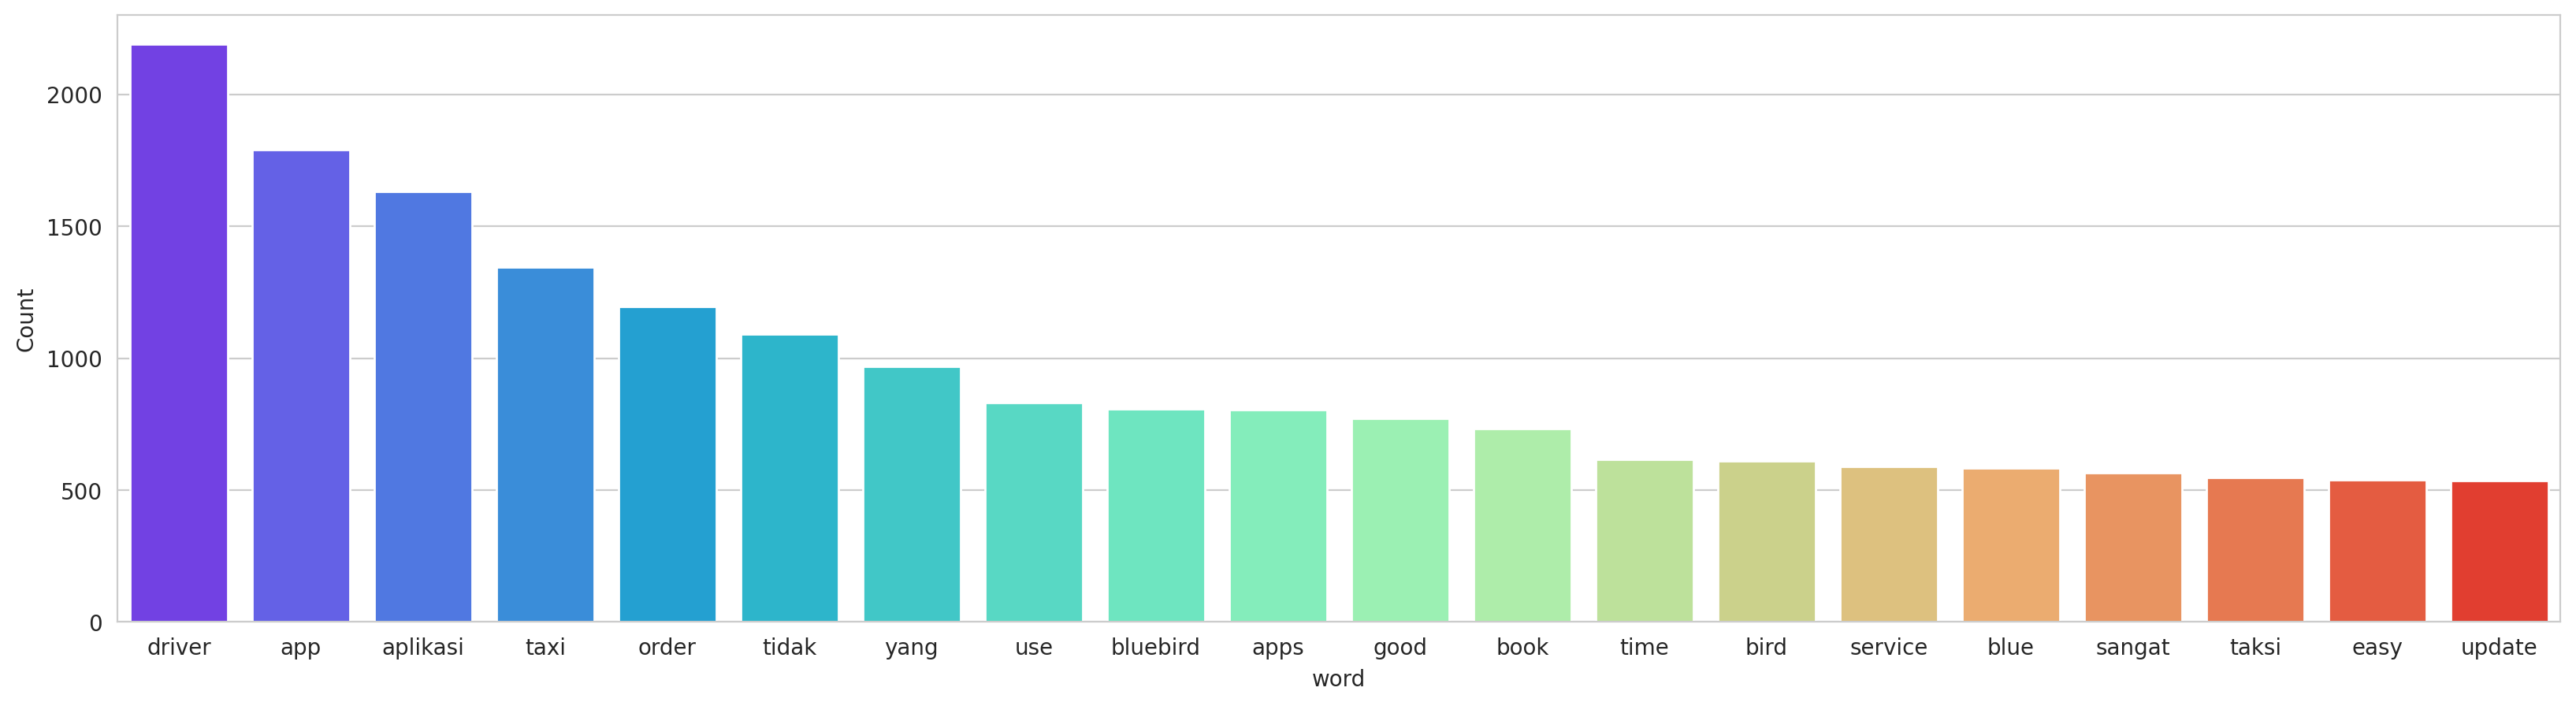

In [20]:
freq_words(df_mbbrev['tokens_stemmed'].apply(lambda x: ' '.join(x)), 20)

In [21]:
custom_stopwords = {"driver", "aplikasi", "app", "car", "taxi", "taksi", "apps", "bluebird", "blue", "bird", "order", "book"}

df_mbbrev['Cleaned_Text'] = df_mbbrev['tokens_stemmed'].apply(
    lambda tokens: ' '.join([word for word in tokens if word not in custom_stopwords])
)

print(df_mbbrev[['tokens_stemmed', 'Cleaned_Text']].head())


                                      tokens_stemmed  \
0               [bikin, aplikasi, tidak, pakai, uat]   
1  [selalu, gagal, add, payment, method, credit, ...   
2  [perusahaan, taksi, andalan, legendaris, maju,...   
3  [get, well, please, give, licence, number, tax...   
4          [good, app, service, many, annoy, advert]   

                                        Cleaned_Text  
0                              bikin tidak pakai uat  
1  selalu gagal add payment method credit card er...  
2               perusahaan andalan legendaris maju u  
3  get well please give licence number well pd nu...  
4                     good service many annoy advert  


In [22]:
df_mbbrev['content'] = df_mbbrev['Cleaned_Text'].astype(str)

In [23]:
df_to_save = df_mbbrev.drop(columns=["tokens", "tokens_stopword_rm", "Cleaned_Text", "Cleaned_Text", "tokens_stemmed"])

df_to_save.to_csv("mybluebird_clean.csv", index=False)



In [24]:
df_mbbrev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,tokens,tokens_stopword_rm,tokens_stemmed,Cleaned_Text
0,c2c92730-0629-496a-86f7-52b2ebd72abf,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,bikin tidak pakai uat,1,0,None,2025-09-21 21:30:38,"Yth Bapak Tri Hartanto, mohon maaf atas ketida...",2025-09-21 21:45:11,None,"[bikin, aplikasi, ga, pakai, uat]","[bikin, aplikasi, ga, pakai, uat]","[bikin, aplikasi, tidak, pakai, uat]",bikin tidak pakai uat
1,702d58d1-030a-441b-b105-7eb005c17753,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,selalu gagal add payment method credit card er...,4,0,6.19.0,2025-09-21 13:03:20,"Yth, Bapak/Ibu Haerun Nur​ , mohon maaf atas k...",2025-09-21 13:26:26,6.19.0,"[selalu, gagal, add, payment, method:, credit,...","[selalu, gagal, add, payment, method:, credit,...","[selalu, gagal, add, payment, method, credit, ...",selalu gagal add payment method credit card er...
2,11cfd27e-fd4d-4ff1-8d38-271b2e1e1a9c,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,perusahaan andalan legendaris maju u,5,0,6.19.0,2025-09-16 08:01:56,"Dear Bapak/Ibu Harimurti Kridalaksana , terima...",2025-09-16 08:07:10,6.19.0,"[perusahaan, taksi, andalan, yang, legendaris....","[perusahaan, taksi, andalan, legendaris., maju...","[perusahaan, taksi, andalan, legendaris, maju,...",perusahaan andalan legendaris maju u
3,4fc0c4fe-bf6c-4ef6-979c-6102efc675cc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,get well please give licence number well pd nu...,3,7,6.18.2,2025-09-15 10:20:12,"Good evening Bapa/Ibu J , Thank you for your r...",2025-09-15 10:55:29,6.18.2,"[getting, better, but, can, you, please, give,...","[getting, better, please, give, licence, numbe...","[get, well, please, give, licence, number, tax...",get well please give licence number well pd nu...
4,0d1e4c23-7a76-4449-925f-2f069fdac414,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,good service many annoy advert,4,0,6.18.2,2025-09-15 00:01:59,"Hi Mr Michael Vaughan , thank you for the rati...",2025-09-15 00:15:29,6.18.2,"[good, app, and, service,, but, too, many, ann...","[good, app, service,, many, annoying, adverts]","[good, app, service, many, annoy, advert]",good service many annoy advert
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9665,2e7a5e6a-e376-47e4-b001-64fe97421afc,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,great sangat membantu,4,1,1.2.127,2011-12-07 23:57:37,None,NaT,1.2.127,"[great, app., sangat, membantu.]","[great, app., sangat, membantu.]","[great, app, sangat, membantu]",great sangat membantu
9666,01814132-db78-47a4-914d-efd23e986e40,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,akhir blackberry dibuat buat androidsemoga sem...,5,1,1.2.126,2011-12-07 02:58:14,None,NaT,1.2.126,"[akhirnya, setelah, di, blackberry,, dibuat, j...","[akhirnya, blackberry,, dibuat, aplikasi, buat...","[akhir, blackberry, dibuat, aplikasi, buat, an...",akhir blackberry dibuat buat androidsemoga sem...
9667,cdc031c1-088a-4619-928c-c7c1cd2d1e75,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,pagi jam 4 pesan berjalan baik muncul notifika...,4,2,1.2.126,2011-12-02 22:11:34,None,NaT,1.2.126,"[pagi, jam, 4, saya, pesan, taksi, berjalan, d...","[pagi, jam, 4, pesan, taksi, berjalan, baik,, ...","[pagi, jam, 4, pesan, taksi, berjalan, baik, m...",pagi jam 4 pesan berjalan baik muncul notifika...
9668,4d2cc639-e04a-40f5-86c8-d654a58f0886,A *********er,https://play-lh.googleusercontent.com/EGemoI2N...,pertama kali make saya seneng banget saya trac...,2,2,1.2.126,2011-11-30 02:24:32,None,NaT,1.2.126,"[pertama, kali, make, app, ini, gw, seneng, ba...","[pertama, kali, make, app, gw, seneng, banget,...","[pertama, kali, make, app, saya, seneng, bange...",pertama kali make saya seneng banget saya trac...


# Sentiment Analysis

In [25]:
from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_mbbrev['sentiment_polarity'] = df_mbbrev['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_mbbrev['sentiment_subjective'] = df_mbbrev['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

In [26]:
df_mbbrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,bikin tidak pakai uat,1,0.000000,0.000000
1,selalu gagal add payment method credit card er...,4,0.000000,0.000000
2,perusahaan andalan legendaris maju u,5,0.000000,0.000000
3,get well please give licence number well pd nu...,3,-0.333333,0.533333
4,good service many annoy advert,4,0.600000,0.550000
...,...,...,...,...
9665,great sangat membantu,4,0.800000,0.750000
9666,akhir blackberry dibuat buat androidsemoga sem...,5,0.000000,0.000000
9667,pagi jam 4 pesan berjalan baik muncul notifika...,4,0.000000,0.000000
9668,pertama kali make saya seneng banget saya trac...,2,0.000000,0.000000


In [27]:
# 50 Positive Review
df_positive = df_mbbrev[df_mbbrev['sentiment_polarity'] > 0].sample(50, random_state=42)

# 50 Negative Review
df_negative = df_mbbrev[df_mbbrev['sentiment_polarity'] < 0].sample(50, random_state=42)

# Merge
df_sampled = pd.concat([df_positive, df_negative])

# Tampilkan hanya kolom yang diinginkan
df_sampled = df_sampled.loc[:, ["content", "score", "sentiment_polarity", "sentiment_subjective"]]

df_sampled.head(10)

,content,score,sentiment_polarity,sentiment_subjective
8474,useful easy use everytime always come time via...,5,0.366667,0.416667
9230,good service,4,0.700000,0.600000
2770,easy use,5,0.433333,0.833333
5184,use huge fan more fact forcefully try advance ...,2,0.163889,0.683333
9278,good,5,0.700000,0.600000
6772,love make travel easy convenient live track th...,5,0.293939,0.566667
3531,share loc bergerak real time,2,0.200000,0.300000
9548,sangat berguna coba beberapa kali selalu berha...,4,0.300000,0.300000
3507,realible trust good manner,5,0.700000,0.600000
3893,good good verry good really happy,5,0.725000,0.700000


Positive Review

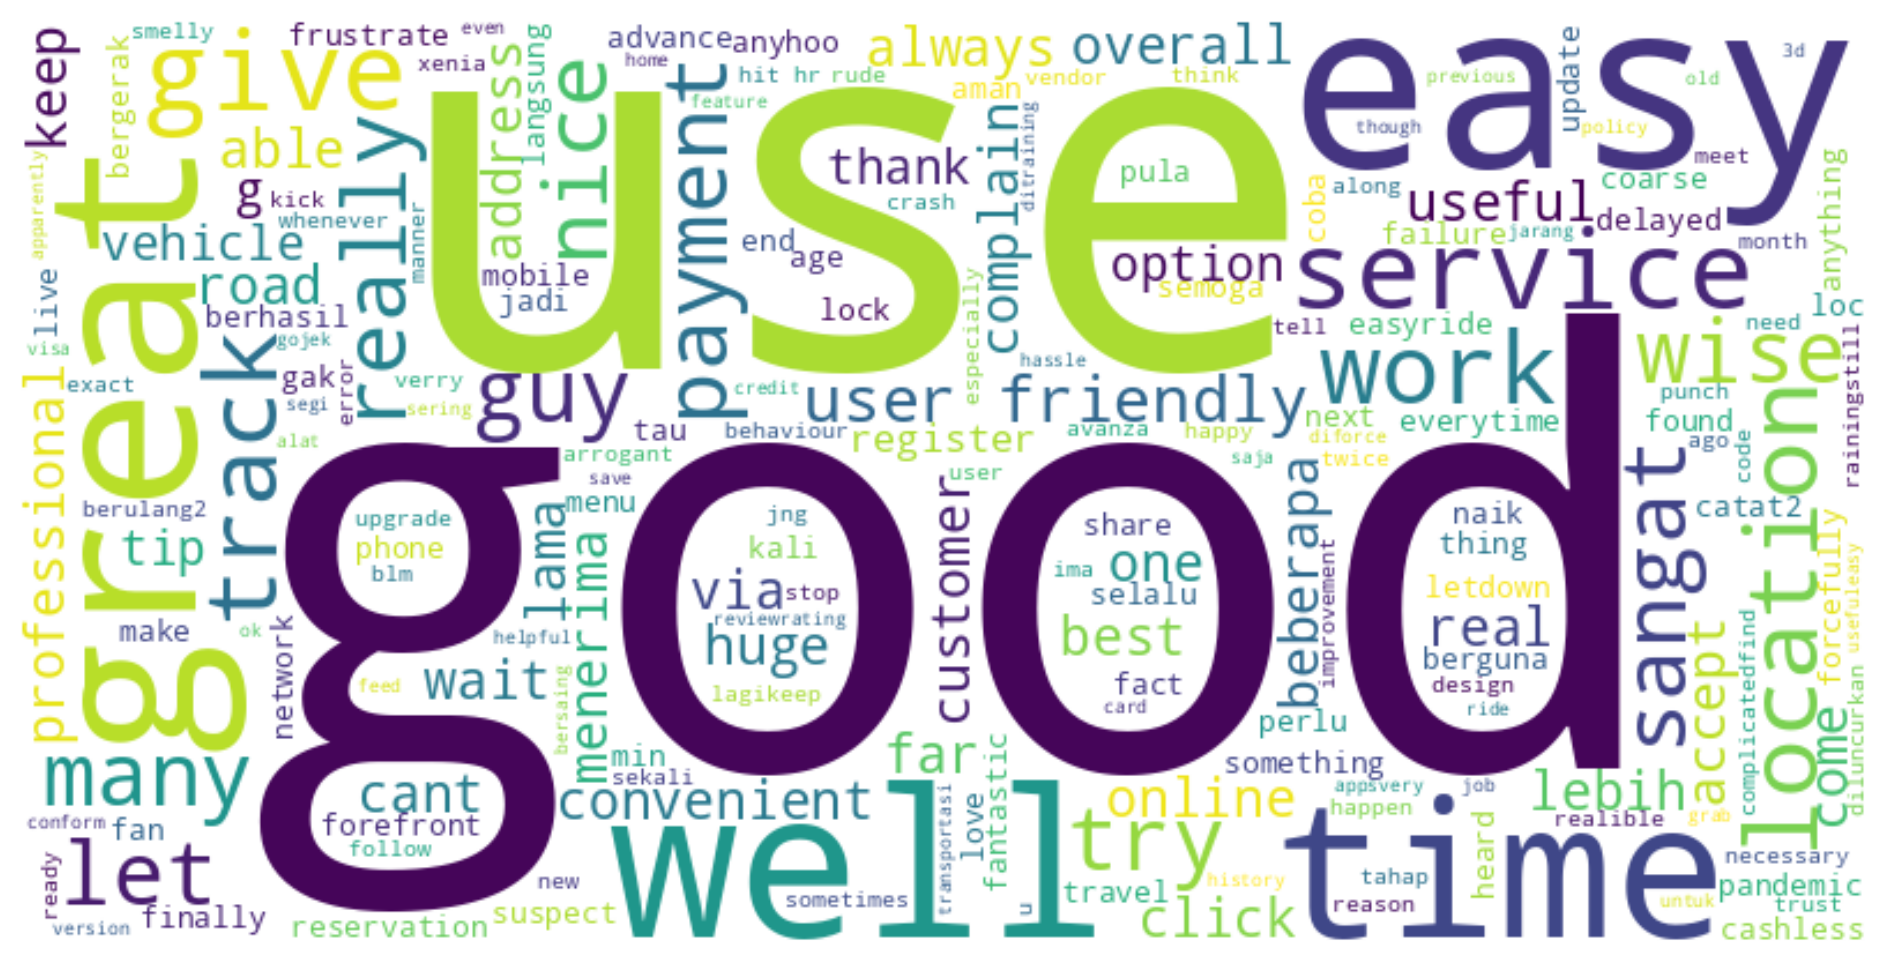

In [28]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Gabungkan semua teks jadi satu
text = " ".join(df_positive['content'].astype(str))

# Buat WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=200
).generate(text)

# Tampilkan
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Negative Review

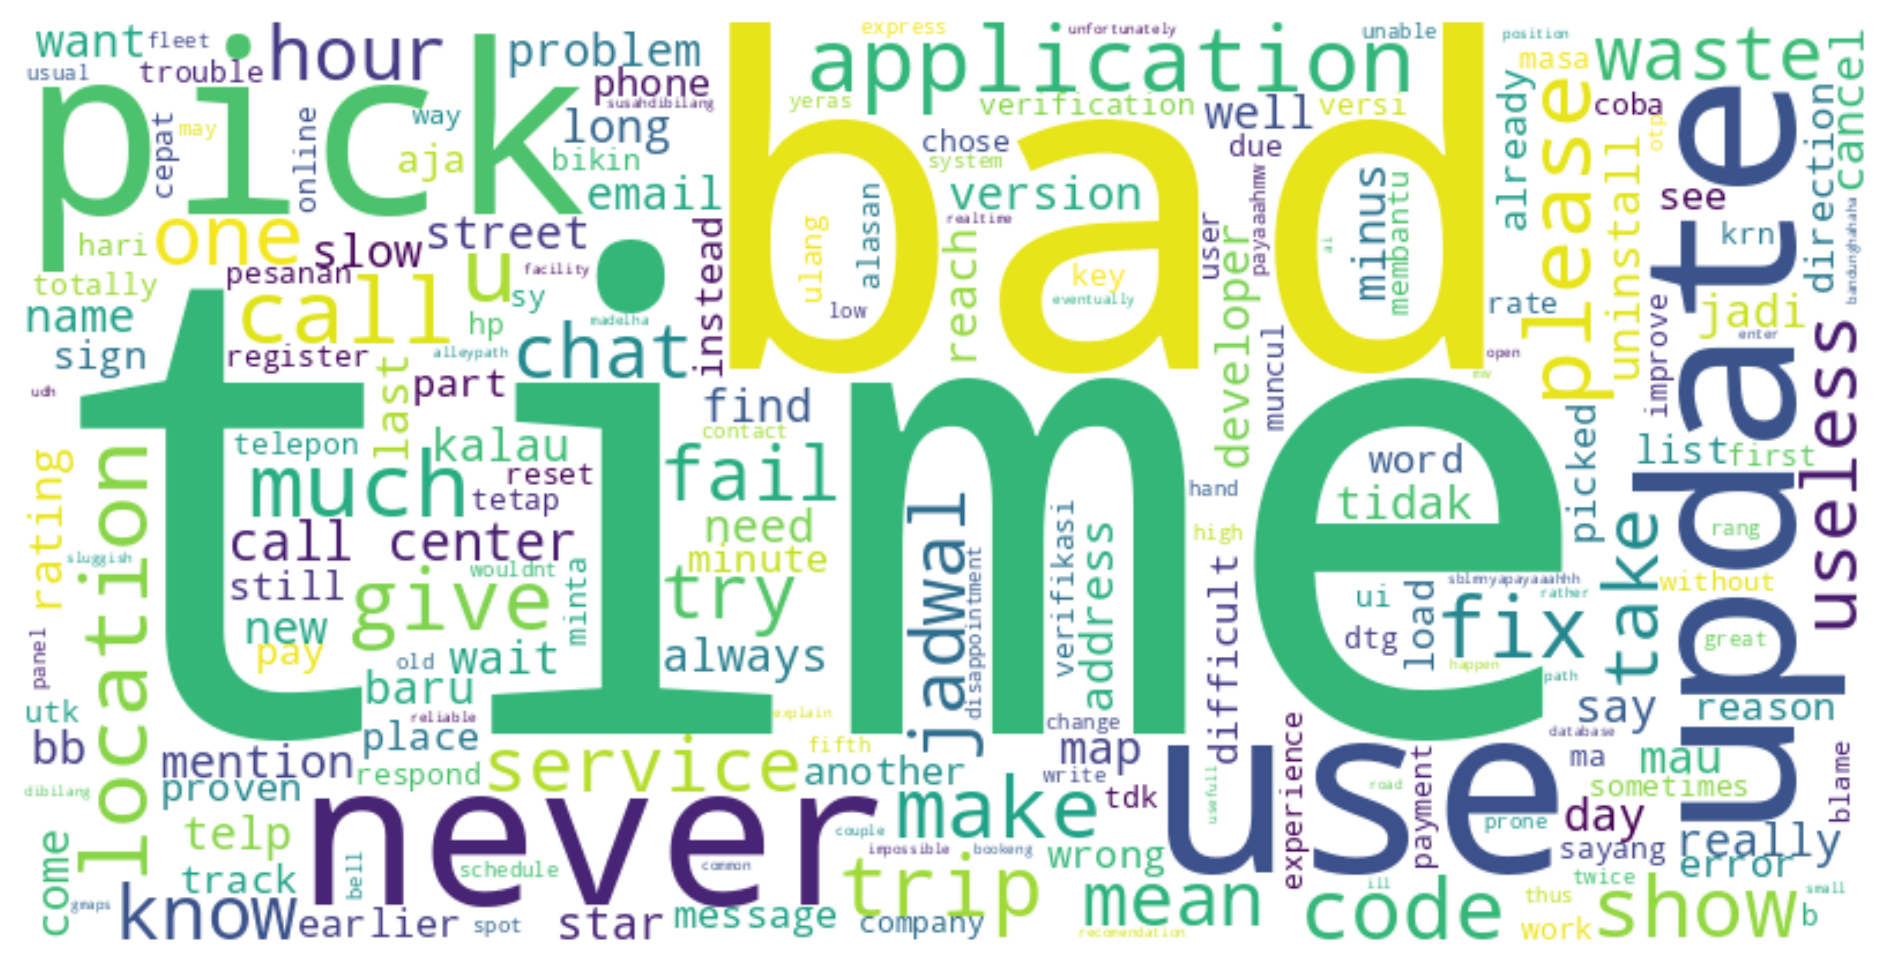

In [29]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Gabungkan semua teks jadi satu
text = " ".join(df_negative['content'].astype(str))

# Buat WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=200
).generate(text)

# Tampilkan
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Vector Count

In [30]:
# texts = df_mbbrev['content'].astype(str).tolist()
texts = df_sampled['content'].astype(str).tolist()

# Inisialisasi CountVectorizer
vectorizer = CountVectorizer()

# Fit dan transform
X = vectorizer.fit_transform(texts)

# Konversi ke DataFrame agar lebih mudah dibaca
import pandas as pd
cv_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Gabungkan dengan df jika ingin
df_cv = pd.concat([df_sampled.reset_index(drop=True), cv_df.reset_index(drop=True)], axis=1)

# Simpan ke CSV
df_cv.to_csv("mybluebird_clean_cv.csv", index=False)

df_cv.head()

,content,score,sentiment_polarity,sentiment_subjective,15,24,30,300000,3d,able,...,would,wouldnt,write,wrong,xenia,xl,ya,yang,yeras,you
0,useful easy use everytime always come time via...,5,0.366667,0.416667,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,good service,4,0.700000,0.600000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,easy use,5,0.433333,0.833333,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,use huge fan more fact forcefully try advance ...,2,0.163889,0.683333,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,good,5,0.700000,0.600000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **TF-IDF**

Install Libraries

In [32]:
!pip install -U nltk
!pip install tensorflow_hub
!pip install xgboost

Import Libraries

In [34]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Device Check

In [35]:
is_cuda = torch.cuda.is_available()
device = torch.device("cuda" if is_cuda else "cpu")
print("Using:", device)

Using: cpu


Load Data

In [37]:
df = pd.read_csv("mybluebird_clean.csv")
print("Dataset shape before:", df.shape)

# Keep only necessary columns
df = df[['content', 'score']].dropna()
print("Dataset shape after:", df.shape)
df.head()

Dataset shape before: (9670, 11)
Dataset shape after: (9582, 2)


,content,score
0,bikin tidak pakai uat,1
1,selalu gagal add payment method credit card er...,4
2,perusahaan andalan legendaris maju u,5
3,get well please give licence number well pd nu...,3
4,good service many annoy advert,4


Label Encoding

In [38]:
def score_to_sentiment(score):
    if score <= 2:
        return 0   # negative
    elif score >= 4:
        return 1   # positive
    else:
        return None  # drop neutral

df['sentiment'] = df['score'].apply(score_to_sentiment)
df = df.dropna(subset=['sentiment'])
df['sentiment'] = df['sentiment'].astype(int)

print("Dataset shape after:", df.shape)
print(df['sentiment'].value_counts())

Dataset shape after: (8786, 3)
sentiment
1    4677
0    4109
Name: count, dtype: int64


Preprocess Text

In [42]:
def preprocess_text(text):
    text = re.sub(r'<[^>]*>', '', str(text))
    text = text.strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['content'] = df['content'].apply(preprocess_text)

TRAIN TEST SPLIT

In [43]:
x = df['content']
y = df['sentiment']

xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

Classifiers

In [44]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from timeit import default_timer as timer

svm_classifier = LinearSVC()
logistic_regression = LogisticRegression(max_iter=1000)
nb_classifier = MultinomialNB()
xgboost_classifier = XGBClassifier()
random_forest_classifier = RandomForestClassifier(
    n_estimators=100, max_depth=3, max_features='sqrt',
    min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=0
)

def evaluate_model(model, xtest, ytest):
    y_pred = model.predict(xtest)
    return (
        y_pred,
        accuracy_score(ytest, y_pred),
        precision_score(ytest, y_pred),
        recall_score(ytest, y_pred),
        f1_score(ytest, y_pred),
        classification_report(ytest, y_pred),
        confusion_matrix(ytest, y_pred),
    )

batch_size = 1000


**1. TF-IDF**

In [51]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

start = timer()
tfidf_vectorizer_xtrain = tfidf_vectorizer.fit_transform(xtrain).toarray()
tfidf_vectorizer_xtest = tfidf_vectorizer.transform(xtest).toarray()
print("TFIDF embedding time:", timer() - start)

# Train classifiers dengan objek baru (supaya nggak ketimpa)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

svm_tfidf = LinearSVC().fit(tfidf_vectorizer_xtrain, ytrain)
lr_tfidf  = LogisticRegression(max_iter=1000).fit(tfidf_vectorizer_xtrain, ytrain)
nb_tfidf  = MultinomialNB().fit(tfidf_vectorizer_xtrain, ytrain)
xgb_tfidf = XGBClassifier(use_label_encoder=False, eval_metric="logloss").fit(tfidf_vectorizer_xtrain, ytrain)
rfc_tfidf = RandomForestClassifier().fit(tfidf_vectorizer_xtrain, ytrain)

# Evaluate contoh (boleh skip kalau langsung mau ke akurasi semua model)
y_pred_svm, accuracy_svm, precision_svm, recall_svm, f1_svm, report_svm, cm_svm = evaluate_model(
    svm_tfidf, tfidf_vectorizer_xtest, ytest
)
print("SVM TFIDF Accuracy:", accuracy_svm)


TFIDF embedding time: 0.7066063019997273


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:38:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM TFIDF Accuracy: 0.8691695108077361


**2. Universal Sentence Encoder (USE)**

In [54]:
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

start = timer()
xtrain_use = np.array(embed(xtrain.tolist()))
xtest_use = np.array(embed(xtest.tolist()))
print("USE embedding time:", timer() - start)

# Train classifiers dengan objek baru (supaya tidak ketimpa TF-IDF/TFIDF+USE)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

svm_use = LinearSVC().fit(xtrain_use, ytrain)
lr_use  = LogisticRegression(max_iter=1000).fit(xtrain_use, ytrain)
xgb_use = XGBClassifier(use_label_encoder=False, eval_metric="logloss").fit(xtrain_use, ytrain)
rfc_use = RandomForestClassifier().fit(xtrain_use, ytrain)

# Evaluasi contoh
y_pred_svm_use, accuracy_svm_use, _, _, _, _, _ = evaluate_model(svm_use, xtest_use, ytest)
print("SVM USE Accuracy:", accuracy_svm_use)

USE embedding time: 3.7097723609999775


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:46:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM USE Accuracy: 0.8270762229806599


**3. TF-IDF + USE**

In [47]:
xtrain_combined = np.concatenate([tfidf_vectorizer_xtrain, xtrain_use], axis=1)
xtest_combined = np.concatenate([tfidf_vectorizer_xtest, xtest_use], axis=1)

svm_tfidf_use = svm_classifier.fit(xtrain_combined, ytrain)
lr_tfidf_use = logistic_regression.fit(xtrain_combined, ytrain)
xgboost_tfidf_use = xgboost_classifier.fit(xtrain_combined, ytrain)
rfc_tfidf_use = random_forest_classifier.fit(xtrain_combined, ytrain)

y_pred_svm_tfidf_use, accuracy_svm_tfidf_use, _, _, _, _, _ = evaluate_model(
    svm_tfidf_use, xtest_combined, ytest
)
print("SVM TFIDF+USE Accuracy:", accuracy_svm_tfidf_use)

SVM TFIDF+USE Accuracy: 0.8686006825938567


Visualization TF-IDF

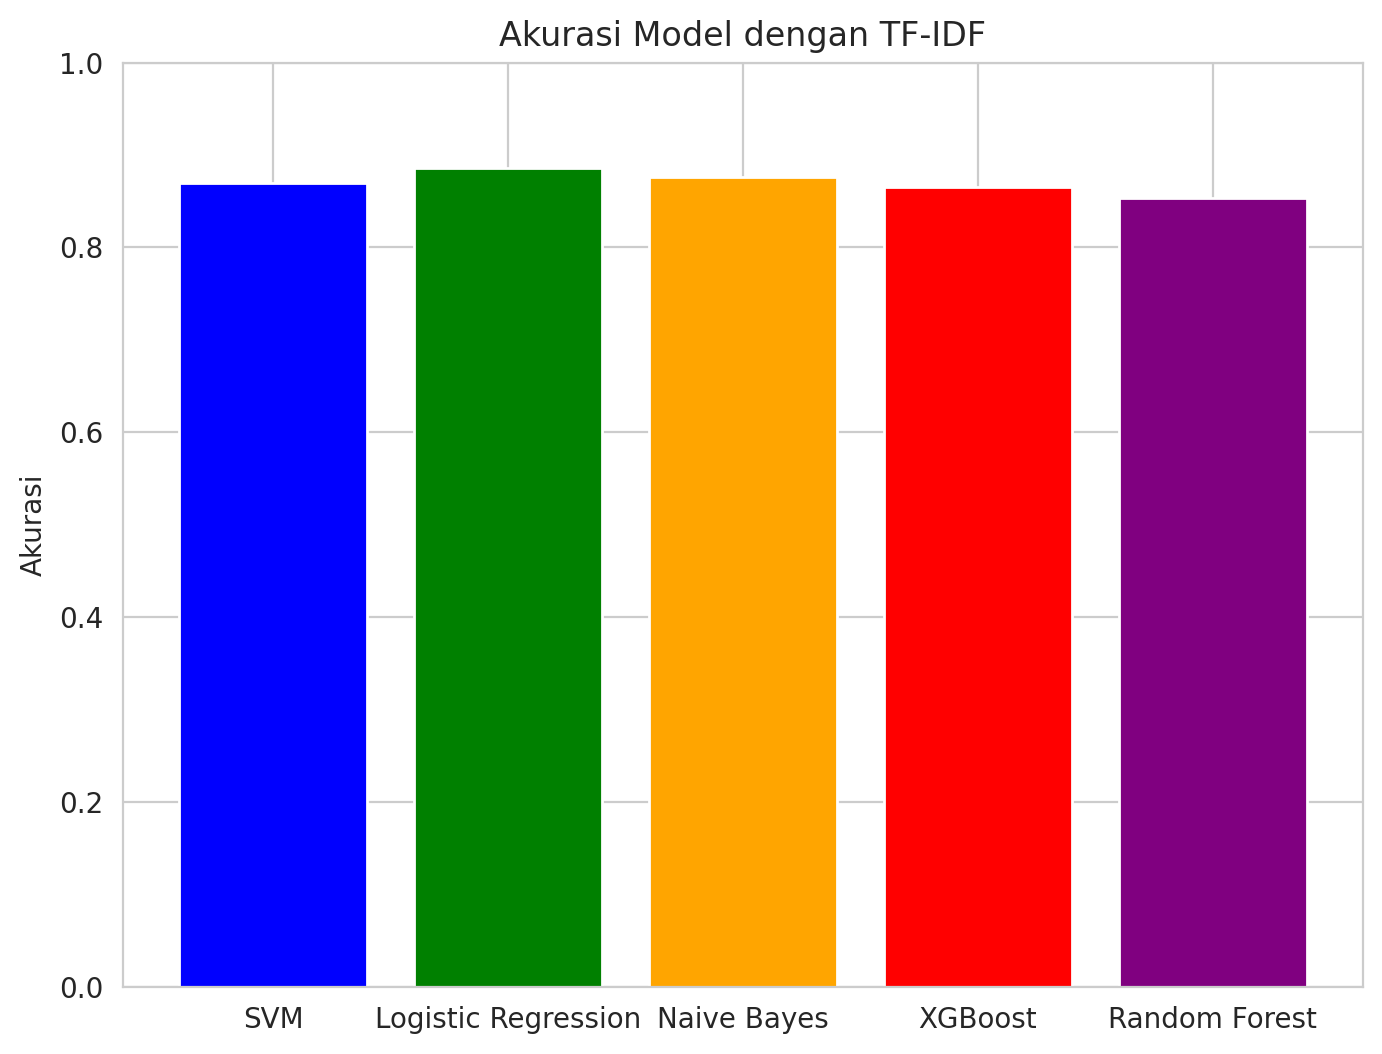

In [56]:
accuracy_svm_tfidf = evaluate_model(svm_tfidf, tfidf_vectorizer_xtest, ytest)[1]
accuracy_lr_tfidf  = evaluate_model(lr_tfidf, tfidf_vectorizer_xtest, ytest)[1]
accuracy_nb_tfidf  = evaluate_model(nb_tfidf, tfidf_vectorizer_xtest, ytest)[1]
accuracy_xgb_tfidf = evaluate_model(xgb_tfidf, tfidf_vectorizer_xtest, ytest)[1]
accuracy_rfc_tfidf = evaluate_model(rfc_tfidf, tfidf_vectorizer_xtest, ytest)[1]

models_tfidf = ["SVM", "Logistic Regression", "Naive Bayes", "XGBoost", "Random Forest"]
tfidf_accuracies = [accuracy_svm_tfidf, accuracy_lr_tfidf, accuracy_nb_tfidf, accuracy_xgb_tfidf, accuracy_rfc_tfidf]

plt.figure(figsize=(8,6))
plt.bar(models_tfidf, tfidf_accuracies, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.title("Akurasi Model dengan TF-IDF")
plt.ylabel("Akurasi")
plt.ylim(0,1)
plt.show()

Visualization USE

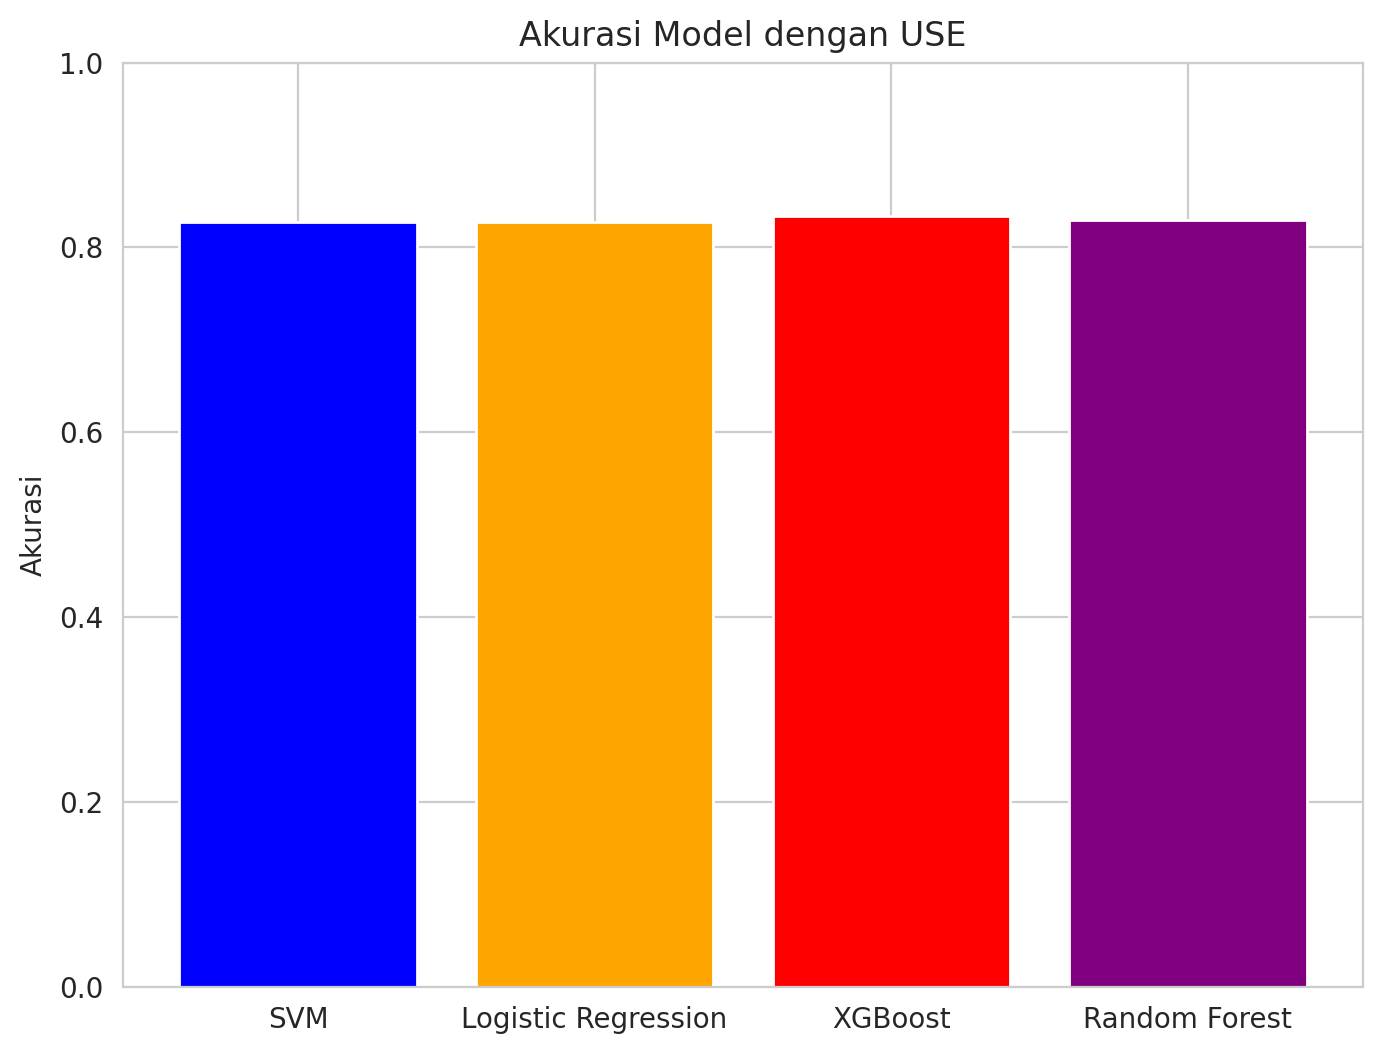

In [57]:
accuracy_svm_use = evaluate_model(svm_use, xtest_use, ytest)[1]
accuracy_lr_use  = evaluate_model(lr_use, xtest_use, ytest)[1]
accuracy_xgb_use = evaluate_model(xgb_use, xtest_use, ytest)[1]
accuracy_rfc_use = evaluate_model(rfc_use, xtest_use, ytest)[1]

models_use = ["SVM", "Logistic Regression", "XGBoost", "Random Forest"]
use_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgb_use, accuracy_rfc_use]

plt.figure(figsize=(8,6))
plt.bar(models_use, use_accuracies, color=['blue', 'orange', 'red', 'purple'])
plt.title("Akurasi Model dengan USE")
plt.ylabel("Akurasi")
plt.ylim(0,1)
plt.show()

Visualization TF-IDF + USE

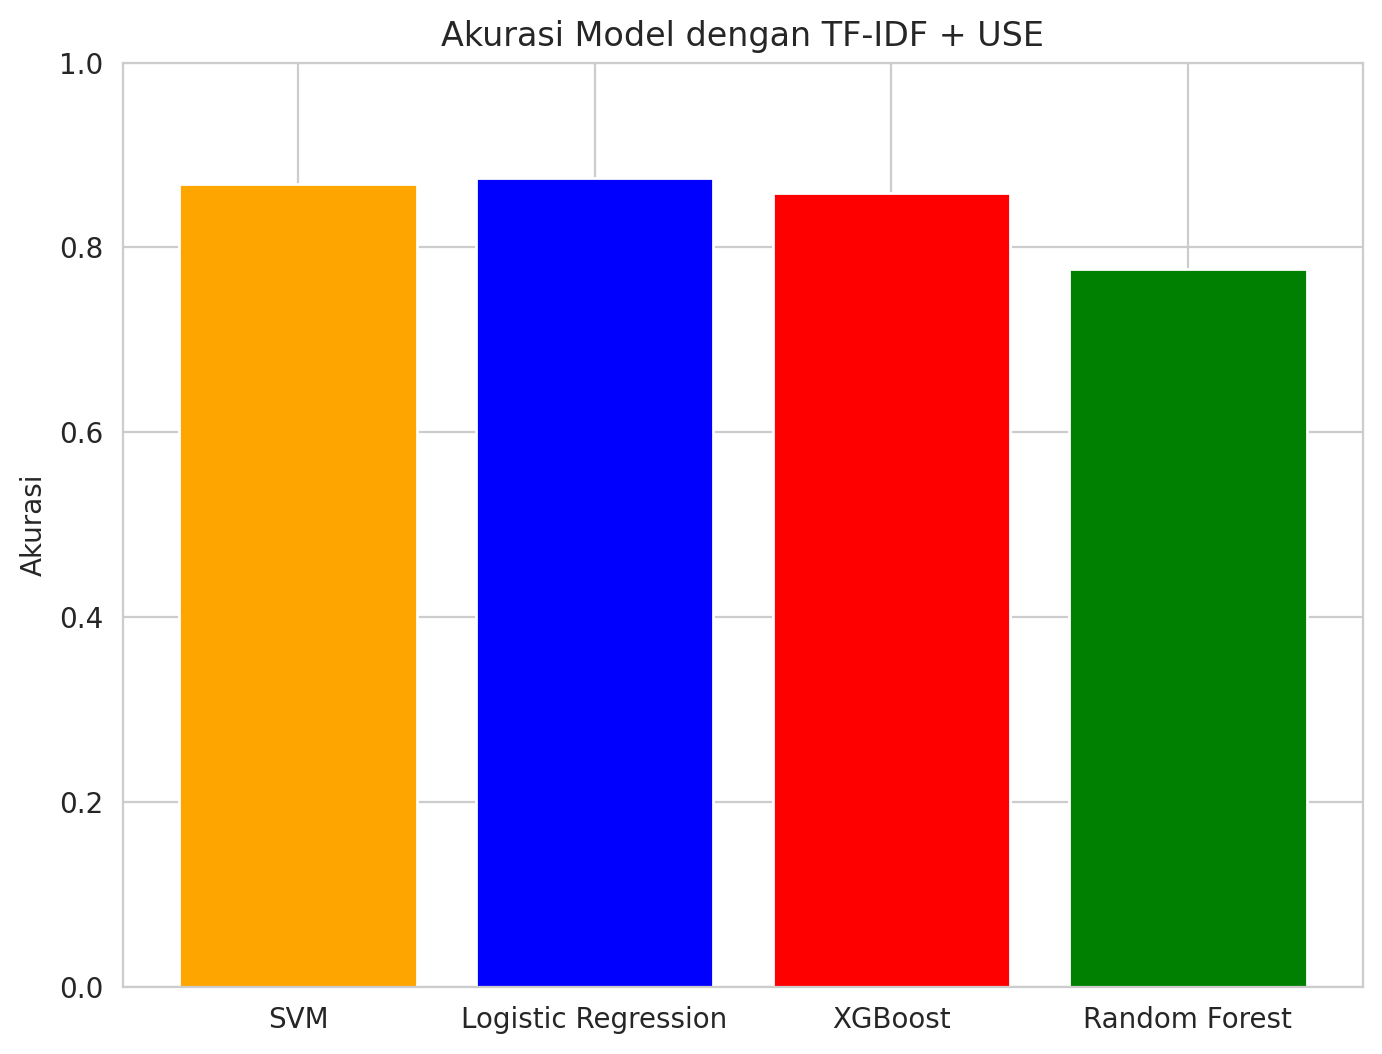

In [60]:
accuracy_svm_comb = evaluate_model(svm_tfidf_use, xtest_combined, ytest)[1]
accuracy_lr_comb  = evaluate_model(lr_tfidf_use, xtest_combined, ytest)[1]
accuracy_xgb_comb = evaluate_model(xgboost_tfidf_use, xtest_combined, ytest)[1]
accuracy_rfc_comb = evaluate_model(rfc_tfidf_use, xtest_combined, ytest)[1]

models_comb = ["SVM", "Logistic Regression", "XGBoost", "Random Forest"]
combined_accuracies = [accuracy_svm_comb, accuracy_lr_comb, accuracy_xgb_comb, accuracy_rfc_comb]

plt.figure(figsize=(8,6))
plt.bar(models_comb, combined_accuracies, color=['orange', 'blue', 'red', 'green'])
plt.title("Akurasi Model dengan TF-IDF + USE")
plt.ylabel("Akurasi")
plt.ylim(0,1)
plt.show()

Visualization

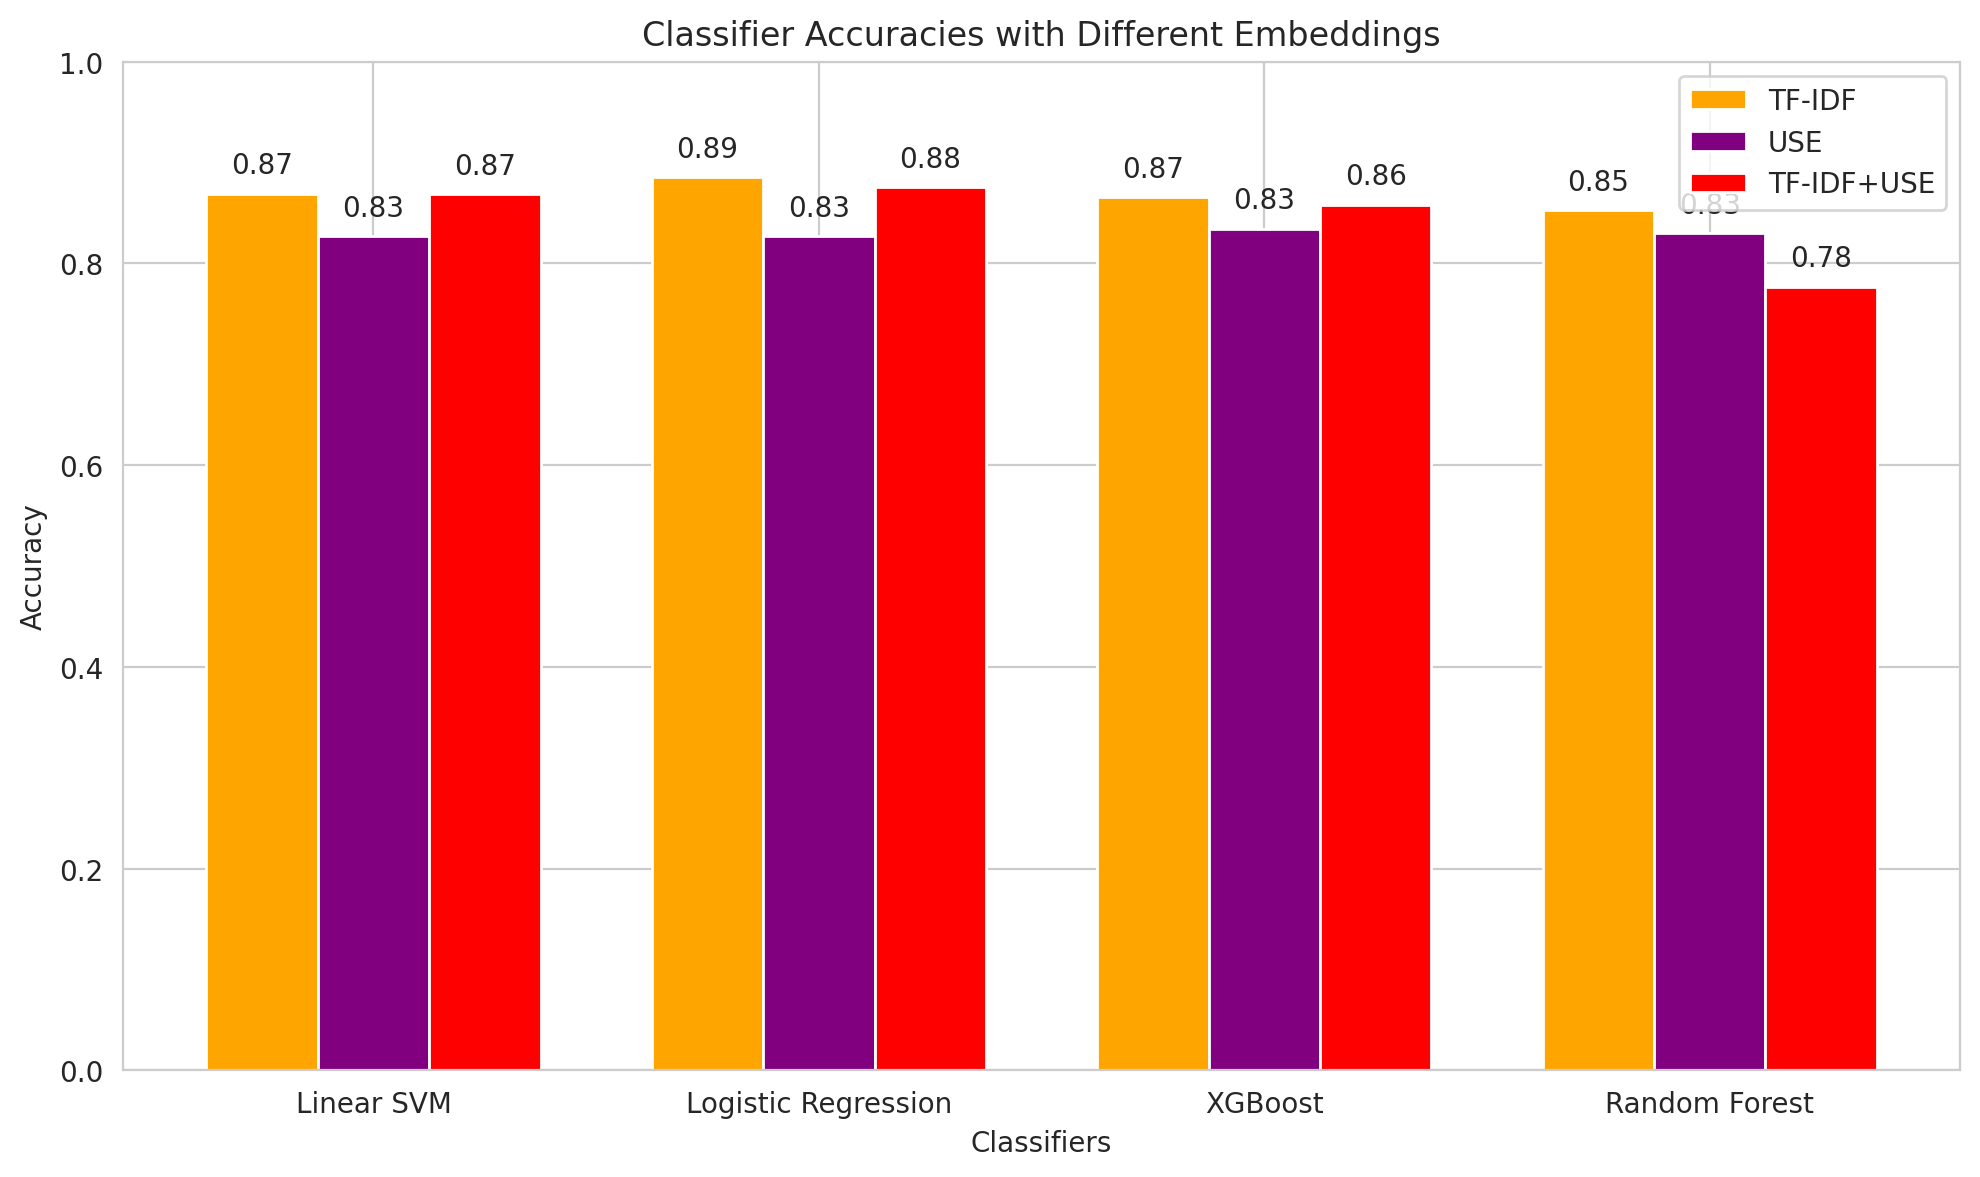

In [62]:
# Define the classifiers and their corresponding accuracies
classifiers = ["Linear SVM", "Logistic Regression", "XGBoost", "Random Forest"]

# TF-IDF
tfidf_accuracies = [
    accuracy_svm_tfidf,
    accuracy_lr_tfidf,
    accuracy_xgb_tfidf,
    accuracy_rfc_tfidf
]

# USE
use_accuracies = [
    accuracy_svm_use,
    accuracy_lr_use,
    accuracy_xgb_use,
    accuracy_rfc_use
]

# TF-IDF + USE
tfidf_use_accuracies = [
    accuracy_svm_comb,
    accuracy_lr_comb,
    accuracy_xgb_comb,
    accuracy_rfc_comb
]

# Create an index for the x-axis
x = np.arange(len(classifiers))

# Set the width of the bars
bar_width = 0.25

# Create a grouped bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, tfidf_accuracies, bar_width, label='TF-IDF', color='orange')
plt.bar(x, use_accuracies, bar_width, label='USE', color='purple')
plt.bar(x + bar_width, tfidf_use_accuracies, bar_width, label='TF-IDF+USE', color='red')

# Set labels, title, and legend
plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracies with Different Embeddings')
plt.xticks(x, classifiers)
plt.ylim(0, 1.0)
plt.legend()

# Add accuracy values on top of the bars
for i in range(len(classifiers)):
    plt.text(x[i] - bar_width, tfidf_accuracies[i] + 0.02, f"{tfidf_accuracies[i]:.2f}", ha='center')
    plt.text(x[i], use_accuracies[i] + 0.02, f"{use_accuracies[i]:.2f}", ha='center')
    plt.text(x[i] + bar_width, tfidf_use_accuracies[i] + 0.02, f"{tfidf_use_accuracies[i]:.2f}", ha='center')

# Display the plot
plt.tight_layout()
plt.show()
